# Positive matrix-valued transport on a line

This notebook generates the positive $2\times2$ matrix-valued figure used in the section on vector- and matrix-valued measures.  The base is one-dimensional, while each point carries a positive semidefinite matrix

$$A_t(x)\in\mathbb S_+^2.$$

The conservative model uses a matrix density $A_t$ and a spatial matrix flux $P_t$ satisfying

$$
\partial_t A_t+\partial_x P_t=0,
\qquad
\int_0^1\!\int \operatorname{tr}(P_t^\top A_t^\dagger P_t)\,dx\,dt.
$$

Both endpoints are mixtures of two localized matrix modes.  Each mode is a scalar Gaussian bump times a fixed positive matrix, so its two eigenvalue profiles are Gaussian bumps with the same spatial center.  The left panel is the commuting/diagonal analogue of independent positive vector channels.  The right panel is a strongly coupled tensor display: packet trajectories are bent toward the transport of the total trace density, and the matrices have different eigendirections, so the local ellipses rotate as packets overlap.


In [1]:
from __future__ import annotations

from dataclasses import dataclass, replace
from pathlib import Path
import contextlib
import io
import sys

from matplotlib.patches import Ellipse
import matplotlib.pyplot as plt
import numpy as np

HERE = Path.cwd().resolve()
ROOT = HERE.parent if HERE.name == "notebooks-figures" else HERE
if not (ROOT / "latex").exists():
    ROOT = Path("/Users/gpeyre/Dropbox/github/ot4ml")

sys.path.insert(0, str(ROOT / "notebooks-figures"))
from figure_style import BLUE, LIGHT_GRAY, RED, box_axes, interp_color, save_pdf, setup_matplotlib

setup_matplotlib()

FIGURE_NAME = "matrix-valued-measure-geodesic"
OUT_DIR = ROOT / "latex" / "figures" / FIGURE_NAME
OUT_DIR.mkdir(parents=True, exist_ok=True)
THUMB_DIR = ROOT / "notebooks-figures" / "thumbnails"
THUMB_DIR.mkdir(parents=True, exist_ok=True)


## Matrix packets and common-mode bending

Each scalar packet is a Gaussian density multiplied by a fixed positive semidefinite matrix $B_r\succeq0$,

$$A_t(x)=\sum_r \rho_{r,t}(x)B_r.$$

For the independent display, packet means and standard deviations interpolate linearly.  For the strongly coupled display, the packet mean is bent toward the transport of the total trace density during the middle of the interpolation.  The bending factor is again $\gamma\sin(\pi t)$, hence the endpoints and the total matrix mass are unchanged.


In [2]:
@dataclass(frozen=True)
class MatrixPacket:
    mass: float
    mean0: float
    sigma0: float
    mean1: float
    sigma1: float
    matrix: np.ndarray
    common_mean1: float | None = None


def gaussian_density(x: np.ndarray, mean: float, sigma: float) -> np.ndarray:
    return np.exp(-0.5 * ((x - mean) / sigma) ** 2) / (np.sqrt(2 * np.pi) * sigma)


def rotation(theta: float) -> np.ndarray:
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s], [s, c]])


def psd_from_eigs(eigs: tuple[float, float], theta: float = 0.0) -> np.ndarray:
    R = rotation(theta)
    B = R @ np.diag(eigs) @ R.T
    return B / np.trace(B)


def packet_parameters(packet: MatrixPacket, t: float, *, gamma: float) -> tuple[float, float, float, float]:
    independent = (1 - t) * packet.mean0 + t * packet.mean1
    independent_dot = packet.mean1 - packet.mean0
    common_target = packet.mean1 if packet.common_mean1 is None else packet.common_mean1
    common = (1 - t) * packet.mean0 + t * common_target
    common_dot = common_target - packet.mean0
    bend = gamma * np.sin(np.pi * t)
    bend_dot = gamma * np.pi * np.cos(np.pi * t)
    mean = (1 - bend) * independent + bend * common
    mean_dot = (1 - bend) * independent_dot + bend * common_dot + bend_dot * (common - independent)
    sigma = (1 - t) * packet.sigma0 + t * packet.sigma1
    sigma_dot = packet.sigma1 - packet.sigma0
    return mean, sigma, mean_dot, sigma_dot


def packet_density(x: np.ndarray, packet: MatrixPacket, t: float, *, gamma: float) -> np.ndarray:
    mean, sigma, _, _ = packet_parameters(packet, t, gamma=gamma)
    return packet.mass * gaussian_density(x, mean, sigma)


def packet_velocity(x: np.ndarray, packet: MatrixPacket, t: float, *, gamma: float) -> np.ndarray:
    mean, sigma, mean_dot, sigma_dot = packet_parameters(packet, t, gamma=gamma)
    return mean_dot + sigma_dot * (x - mean) / sigma


def matrix_field(x: np.ndarray, packets: list[MatrixPacket], t: float, *, gamma: float) -> np.ndarray:
    A = np.zeros((len(x), 2, 2), dtype=float)
    for packet in packets:
        rho = packet_density(x, packet, t, gamma=gamma)
        A += rho[:, None, None] * packet.matrix[None, :, :]
    return 0.5 * (A + np.swapaxes(A, -1, -2))


def matrix_flux(x: np.ndarray, packets: list[MatrixPacket], t: float, *, gamma: float) -> np.ndarray:
    P = np.zeros((len(x), 2, 2), dtype=float)
    for packet in packets:
        rho = packet_density(x, packet, t, gamma=gamma)
        velocity = packet_velocity(x, packet, t, gamma=gamma)
        P += (rho * velocity)[:, None, None] * packet.matrix[None, :, :]
    return 0.5 * (P + np.swapaxes(P, -1, -2))


def trace_density_endpoint(x: np.ndarray, packets: list[MatrixPacket], *, endpoint: int) -> np.ndarray:
    rho = np.zeros_like(x, dtype=float)
    for packet in packets:
        mean = packet.mean0 if endpoint == 0 else packet.mean1
        sigma = packet.sigma0 if endpoint == 0 else packet.sigma1
        rho += packet.mass * np.trace(packet.matrix) * gaussian_density(x, mean, sigma)
    dx = x[1] - x[0]
    rho *= sum(packet.mass * np.trace(packet.matrix) for packet in packets) / max(float(rho.sum() * dx), 1e-15)
    return rho


def inverse_cdf(x: np.ndarray, rho: np.ndarray, q: np.ndarray) -> np.ndarray:
    dx = x[1] - x[0]
    cdf = np.cumsum(rho) * dx
    cdf[-1] = float(rho.sum() * dx)
    return np.interp(q, np.r_[0.0, cdf], np.r_[x[0], x])


def cdf_values(x: np.ndarray, rho: np.ndarray, positions: np.ndarray) -> np.ndarray:
    dx = x[1] - x[0]
    cdf = np.cumsum(rho) * dx
    cdf[-1] = float(rho.sum() * dx)
    return np.interp(positions, x, cdf, left=0.0, right=cdf[-1])


def attach_common_targets(x: np.ndarray, packets: list[MatrixPacket]) -> list[MatrixPacket]:
    rho0 = trace_density_endpoint(x, packets, endpoint=0)
    rho1 = trace_density_endpoint(x, packets, endpoint=1)
    means0 = np.array([packet.mean0 for packet in packets])
    q = cdf_values(x, rho0, means0)
    common_targets = inverse_cdf(x, rho1, q)
    return [replace(packet, common_mean1=float(target)) for packet, target in zip(packets, common_targets)]


def total_matrix_mass(x: np.ndarray, field: np.ndarray) -> np.ndarray:
    return np.trapezoid(field, x=x, axis=0)


def continuity_residual(x: np.ndarray, packets: list[MatrixPacket], t: float, *, gamma: float, dt: float = 2e-4) -> float:
    dA_dt = (matrix_field(x, packets, t + dt, gamma=gamma) - matrix_field(x, packets, t - dt, gamma=gamma)) / (2 * dt)
    dP_dx = np.gradient(matrix_flux(x, packets, t, gamma=gamma), x, axis=0, edge_order=2)
    residual = dA_dt + dP_dx
    interior = slice(8, -8)
    scale = max(float(np.max(np.abs(dA_dt[interior]))), 1e-12)
    return float(np.max(np.abs(residual[interior])) / scale)


## Endpoint data

There are two localized matrix modes at the source and two at the target.  In the commuting panel, each mode has diagonal eigenvalue profiles sharing one Gaussian center.  In the coupled panel, the same two-mode kinematics are used with non-diagonal positive matrices and common-mode bending.


In [3]:
x = np.linspace(-2.80, 2.80, 860)
x_glyph = np.linspace(-2.34, 2.34, 29)
times = np.linspace(0, 1, 9)

# Two localized modes.  Each mode is a Gaussian scalar profile times a PSD matrix,
# hence both eigenvalue profiles are centered at the same spatial location.
packet_kinematics = [
    (0.52, -1.48, 0.16, 1.42, 0.17),
    (0.48, 0.78, 0.18, -0.70, 0.16),
]

diagonal_matrices = [
    psd_from_eigs((0.96, 0.20), 0.0),
    psd_from_eigs((0.24, 0.90), 0.0),
]

oriented_matrices = [
    psd_from_eigs((0.98, 0.20), np.deg2rad(24)),
    psd_from_eigs((0.92, 0.22), np.deg2rad(112)),
]

packets_independent = [MatrixPacket(*params, matrix=B) for params, B in zip(packet_kinematics, diagonal_matrices)]
packets_coupled = [MatrixPacket(*params, matrix=B) for params, B in zip(packet_kinematics, oriented_matrices)]
packets_coupled = attach_common_targets(x, packets_coupled)

for packets, gamma in ((packets_independent, 0.0), (packets_coupled, 0.94)):
    masses = [total_matrix_mass(x, matrix_field(x, packets, t, gamma=gamma)) for t in times]
    for M in masses[1:]:
        np.testing.assert_allclose(M, masses[0], rtol=1e-5, atol=1e-5)
    eigmins = []
    for t in times:
        vals = np.linalg.eigvalsh(matrix_field(x_glyph, packets, t, gamma=gamma))
        eigmins.append(float(vals.min()))
    if min(eigmins) < -1e-12:
        raise RuntimeError("Matrix field lost positive semidefiniteness.")
    residuals = [continuity_residual(x, packets, t, gamma=gamma) for t in (0.25, 0.50, 0.75)]
    if max(residuals) > 3e-3:
        raise RuntimeError(f"Continuity residual too large: {residuals}")

print("total matrix mass, independent panel:\n", total_matrix_mass(x, matrix_field(x, packets_independent, 0.0, gamma=0.0)))
print("total matrix mass, coupled panel:\n", total_matrix_mass(x, matrix_field(x, packets_coupled, 0.0, gamma=0.94)))
print("common targets:", [round(packet.common_mean1 or packet.mean1, 3) for packet in packets_coupled])
print("relative continuity residuals:", [continuity_residual(x, packets_coupled, t, gamma=0.94) for t in (0.25, 0.50, 0.75)])


total matrix mass, independent panel:
 [[0.53139746 0.        ]
 [0.         0.46860254]]
total matrix mass, coupled panel:
 [[0.50899176 0.02534944]
 [0.02534944 0.49100824]]
common targets: [-0.683, 1.436]
relative continuity residuals: [0.0005255578818411805, 0.000592431206238913, 0.0005629788490645411]


## Ellipse glyph rendering

At each sampled base location and time, the matrix $A_t(x)$ is represented by an ellipse.  Its axes are the eigenvectors of $A_t(x)$, and the axis lengths are proportional to the square roots of the eigenvalues.  These glyphs are tensor values attached to the base, not velocities.


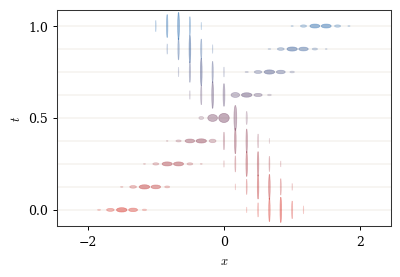

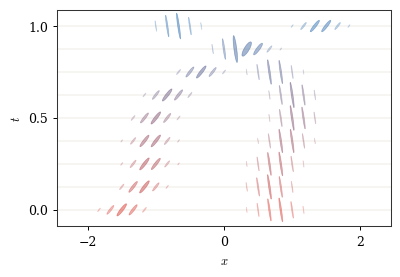

In [4]:
def panel_scale(packets: list[MatrixPacket], *, gamma: float) -> float:
    vals = []
    for t in times:
        field = matrix_field(x_glyph, packets, float(t), gamma=gamma)
        vals.append(np.linalg.eigvalsh(field)[:, -1])
    return max(float(np.quantile(np.concatenate(vals), 0.975)), 1e-12)


scale_independent = panel_scale(packets_independent, gamma=0.0)
scale_coupled = panel_scale(packets_coupled, gamma=0.94)
scale_common = max(scale_independent, scale_coupled)


def draw_matrix_ellipses(ax: plt.Axes, packets: list[MatrixPacket], *, gamma: float, scale: float) -> None:
    for t in times:
        color = interp_color(float(t), RED, BLUE)
        ax.axhline(t, color=LIGHT_GRAY, lw=0.30, zorder=0)
        field = matrix_field(x_glyph, packets, float(t), gamma=gamma)
        for xi, A in zip(x_glyph, field):
            vals, vecs = np.linalg.eigh(A)
            order = np.argsort(vals)[::-1]
            vals = np.maximum(vals[order], 0.0)
            vec = vecs[:, order[0]]
            amp = float(vals[0] / scale)
            if amp < 0.026:
                continue
            amp = min(amp, 1.0)
            minor = min(float(vals[1] / scale), 1.0)
            width = 0.155 * np.sqrt(amp)
            height = 0.050 * np.sqrt(minor)
            angle = np.degrees(np.arctan2(vec[1], vec[0]))
            alpha = 0.16 + 0.30 * amp
            ell = Ellipse(
                (xi, t),
                width=width,
                height=max(height, 0.006),
                angle=angle,
                facecolor=color,
                edgecolor=color,
                lw=0.50,
                alpha=alpha,
                zorder=2,
            )
            ax.add_patch(ell)
    ax.set_xlim(-2.45, 2.45)
    ax.set_ylim(-0.09, 1.09)
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$t$")
    ax.set_xticks([-2, 0, 2])
    ax.set_yticks([0, 0.5, 1])
    box_axes(ax)


def save_panel(filename: str, packets: list[MatrixPacket], *, gamma: float) -> None:
    fig, ax = plt.subplots(figsize=(3.85, 2.62))
    draw_matrix_ellipses(ax, packets, gamma=gamma, scale=scale_common)
    fig.tight_layout(pad=0.18)
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        save_pdf(fig, OUT_DIR / filename, pad_inches=0.025)
    plt.show()


save_panel("independent-ellipses.pdf", packets_independent, gamma=0.0)
save_panel("coupled-ellipses.pdf", packets_coupled, gamma=0.94)


## Thumbnail

The gallery thumbnail combines the independent and strongly coupled tensor displays.  The paper supplies panel labels in LaTeX, so the exported PDFs contain no embedded titles.


Wrote /Users/gpeyre/Dropbox/github/ot4ml/latex/figures/matrix-valued-measure-geodesic/independent-ellipses.pdf
Wrote /Users/gpeyre/Dropbox/github/ot4ml/latex/figures/matrix-valued-measure-geodesic/coupled-ellipses.pdf
Wrote /Users/gpeyre/Dropbox/github/ot4ml/notebooks-figures/thumbnails/matrix-valued-measure-geodesic.png


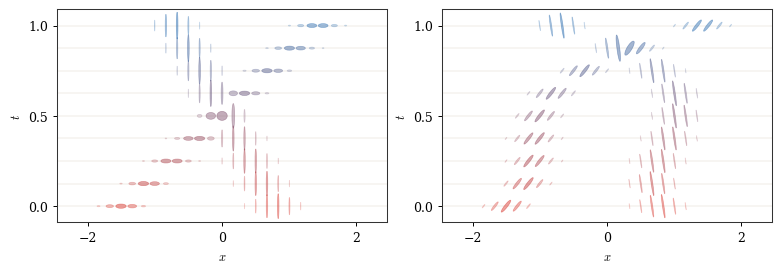

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(7.7, 2.62), constrained_layout=True)
draw_matrix_ellipses(axes[0], packets_independent, gamma=0.0, scale=scale_common)
draw_matrix_ellipses(axes[1], packets_coupled, gamma=0.94, scale=scale_common)
thumb_path = THUMB_DIR / f"{FIGURE_NAME}.png"
fig.savefig(thumb_path, dpi=180, bbox_inches="tight", pad_inches=0.04)
print(f"Wrote {OUT_DIR / 'independent-ellipses.pdf'}")
print(f"Wrote {OUT_DIR / 'coupled-ellipses.pdf'}")
print(f"Wrote {thumb_path}")
plt.show()
